# Evaluación — Módulo de Interpolación y Aproximación

**Programación Científica 2026-1 · Universidad Nacional de Colombia**

mbastidaso@unal.edu.co


[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/)

---

**Integrantes:** (orden alfabético)
- Apellido1, Nombre1: `jauregui jack`
- Apellido2, Nombre2: `_______________`

---

## Instrucciones generales

**Duración:** 1.5 horas

**Recursos permitidos:** internet, LLMs, notebooks del curso. No pueden compartir código ni respuestas con otras parejas.

**Entrega — flujo GitHub obligatorio:**

0. Crear una copia de este archivo que se llama `apellido1_apellido2_evaluacion1.ipynb` en la carpeta EVALUACION y sobre ese archivo se harán todos los resultados/cambios/commits.

1. Crear una rama con el nombre exacto: `apellido1_apellido2_5Junio` (orden alfabético, minúsculas, sin tildes, sin espacios).

2. Trabajen **únicamente sobre esa rama**. Deben hacer **exactamente 3 commits** antes de abrir el PR.

3. Los mensajes de commit deben seguir esta convención y cubrir avance real:
   ```
   init: cedulas, seed y generacion de datos
   add: interpolacion spline y ajuste LS
   add: PCA y analisis escritos
   ```

4. Abran un **Pull Request** de su rama a `main`. En el título del PR escriban: `Evaluación [Apellido1] [Apellido2]`.

⚠️ **Penalizaciones automáticas:**
- Notebook que no ejecuta de principio a fin (`Kernel → Restart & Run All`): −10 pts.
- Menos o más de 3 commits: −5 pts.
- Rama con nombre incorrecto: −5 pts.

---

**Distribución de puntos:**

| Sección | Puntos |
|---|---|
| P0 — Inicialización y datos | 5 |
| P1 — Cuestionario conceptual | 20 |
| P2 — Interpolación B-spline 2D | 30 |
| P3 — Ajuste por mínimos cuadrados | 20 |
| P4 — PCA | 15 |
| GitHub (commits + PR + respuesta) | 10 |
| **Total** | **100** |

---
## P0 — Inicialización (5 pts)

Escriban sus números de cédula en las variables indicadas. **No modifiquen ninguna otra línea de esta sección.** Todos los datos del ejercicio se generan a partir de su semilla.

In [2]:
# TODO P0: reemplacen los ceros con sus ID reales
cedula1 = 1094050841
cedula2 = 1092940889

In [3]:
# 🔒 CELDA DE DATOS — no modificar
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RectBivariateSpline
from scipy.linalg import svd

assert cedula1 != 0 and cedula2 != 0, "Deben ingresar sus ID en la celda anterior."

seed = int((cedula1 + cedula2) % 1000)
rng  = np.random.default_rng(seed)

# Parámetros de la superficie — dependen de la semilla
alpha = 1.0 + (seed % 7)  * 0.3          # frecuencia en x: entre 1.0 y 2.8
beta  = 1.0 + (seed % 5)  * 0.4          # frecuencia en y: entre 1.0 y 2.6
gamma = 0.10 + (seed % 11) * 0.02        # decaimiento gaussiano: entre 0.10 y 0.30
noise_std = 0.05 + (seed % 13) * 0.01    # ruido: entre 0.05 y 0.17

# Malla gruesa de muestreo (15x15 puntos)
n  = 15
x_raw = np.linspace(-3, 3, n)
y_raw = np.linspace(-3, 3, n)
X_raw, Y_raw = np.meshgrid(x_raw, y_raw, indexing='ij')

# Elevación verdadera + ruido
Z_true = np.sin(alpha * X_raw) * np.cos(beta * Y_raw) * np.exp(-gamma * (X_raw**2 + Y_raw**2))
Z_data = Z_true + rng.normal(0, noise_std, X_raw.shape)

print(f"Semilla: {seed}")
print(f"Parámetros — alpha: {alpha:.2f}, beta: {beta:.2f}, gamma: {gamma:.3f}, ruido: {noise_std:.3f}")
print(f"Malla de datos: {n}x{n} puntos en [-3,3]x[-3,3]")
print(f"Z_data shape: {Z_data.shape}")

Semilla: 730
Parámetros — alpha: 1.60, beta: 1.00, gamma: 0.180, ruido: 0.070
Malla de datos: 15x15 puntos en [-3,3]x[-3,3]
Z_data shape: (15, 15)


---
## P1 — Cuestionario conceptual (20 pts)

Respondan las siguientes preguntas **sin ejecutar código adicional**. Basen sus respuestas en la lectura del bloque de generación de datos de P0.

### P1.1 (7 pts)

La celda de datos genera `Z_data = Z_true + ruido`. Cuando construyan el spline en P2, este va a **interpolar** `Z_data`, no `Z_true`.

**a)** ¿Qué significa que el spline interpole `Z_data` en lugar de ajustar `Z_true`? ¿El spline va a pasar exactamente por los valores de `Z_data`?  
**b)** ¿En qué condición sería preferible usar mínimos cuadrados en lugar del spline para reconstruir la superficie?

**Respuesta P1.1:**

a) Que el spline interpole Z_data significa que la superficie generada pasará exactamente por todos y cada uno de los puntos muestreados, incluyendo la desviación provocada por el ruido. En lugar de recuperar la función original suave (Z_true), el modelo memorizará las perturbaciones aleatorias.

b) Sería preferible usar mínimos cuadrados cuando sabemos que nuestros datos están altamente contaminados por ruido y buscamos capturar la tendencia general o subyacente de la superficie (como un modelo paramétrico global), evitando así el sobreajuste (overfitting) que causaría la interpolación estricta.

### P1.2 (7 pts)

En P3 van a ajustar un plano $z = c_0 + c_1 x + c_2 y$ a los datos usando mínimos cuadrados.

**a)** ¿Cómo se construye la matriz $A$ del sistema $A\mathbf{c} = \mathbf{z}$ para este modelo? Descríbanla en términos de sus columnas.  
**b)** La función verdadera `Z_true` no es un plano. ¿Qué representa entonces el plano ajustado? ¿Qué información útil les da sobre la superficie?

**Respuesta P1.2:**

a) Para un sistema de ecuaciones $A\mathbf{c} = \mathbf{z}$ de un plano $z = c_0 + c_1 x + c_2 y$, la matriz $A$ (matriz de diseño) tiene dimensiones $225 \times 3$ (ya que hay $15 \times 15 = 225$ puntos). Sus columnas se construyen así:  Columna 1: Un vector de unos (asociado al coeficiente $c_0$). Columna 2: Un vector con la coordenada $x$ de cada punto de la malla plana (asociado a $c_1$).  Columna 3: Un vector con la coordenada $y$ de cada punto (asociado a $c_2$)

b) El plano ajustado representa la "tendencia lineal global" de la superficie tridimensional. Nos da información útil sobre la inclinación media o el gradiente predominante del terreno a lo largo de las direcciones $x$ e $y$, minimizando la suma de los errores al cuadrado respecto a la superficie real

### P1.3 (6 pts)

En P4 van a aplicar PCA a la nube de puntos $(x_i, y_i, z_i)$ formada por los 225 puntos de la malla.

**a)** ¿Por qué es necesario centrar los datos antes de calcular los componentes principales?  
**b)** ¿Qué interpretación geométrica tiene el primer componente principal en el contexto de esta superficie?

**Respuesta P1.3:

a) Es necesario centrar los datos (restar la media) para que el origen de coordenadas coincida con el centroide de la nube de puntos. De esta forma, los componentes principales (vectores singulares) representarán correctamente las direcciones de máxima varianza de los datos. Si no se centran, el primer componente principal simplemente apuntaría desde el origen $(0,0,0)$ hacia el centro de masa de los datos, sesgando el análisis.

b) Geométricamente, el primer componente principal representa el eje en el espacio 3D a lo largo del cual la nube de puntos $(x_i, y_i, z_i)$ se encuentra más dispersa (es decir, la dirección de máxima variación espacial).

---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"
```

---
## P2 — Interpolación B-spline 2D (27 pts)

Usen `RectBivariateSpline` de `scipy.interpolate` para construir un spline bicúbico sobre los datos `(x_raw, y_raw, Z_data)`.

### P2.1 — Construcción y evaluación (15 pts)

Construyan el spline con `kx=3, ky=3` y evalúenlo en una malla fina de **100×100 puntos** en $[-3,3]\times[-3,3]$.

In [15]:
# TODO P2.1: construir el spline bicúbico y evaluar en malla fina
# Construcción del spline interpolador con kx=3, ky=3 sobre la malla original
spline = RectBivariateSpline(x_raw, y_raw, Z_data, kx=3, ky=3)

# Creación de la malla fina de 100x100
x_fine = np.linspace(-3, 3, 100)
y_fine = np.linspace(-3, 3, 100)
X_fine, Y_fine = np.meshgrid(x_fine, y_fine, indexing='ij')

# Evaluación del spline en la malla fina
Z_fine = spline(x_fine, y_fine)


### P2.2 — Figura comparativa (15 pts)

Produzcan una figura con **dos paneles side-by-side** (`subplot` 1×2):
- Panel izquierdo: `Z_data` en la malla gruesa (superficie en 3D).
- Panel derecho: superficie interpolada por el spline en la malla fina (3D).

Ambos paneles deben tener: colorbar, ejes etiquetados, y usar el **mismo colormap y los mismos límites de color** (`vmin`/`vmax` iguales en ambos).

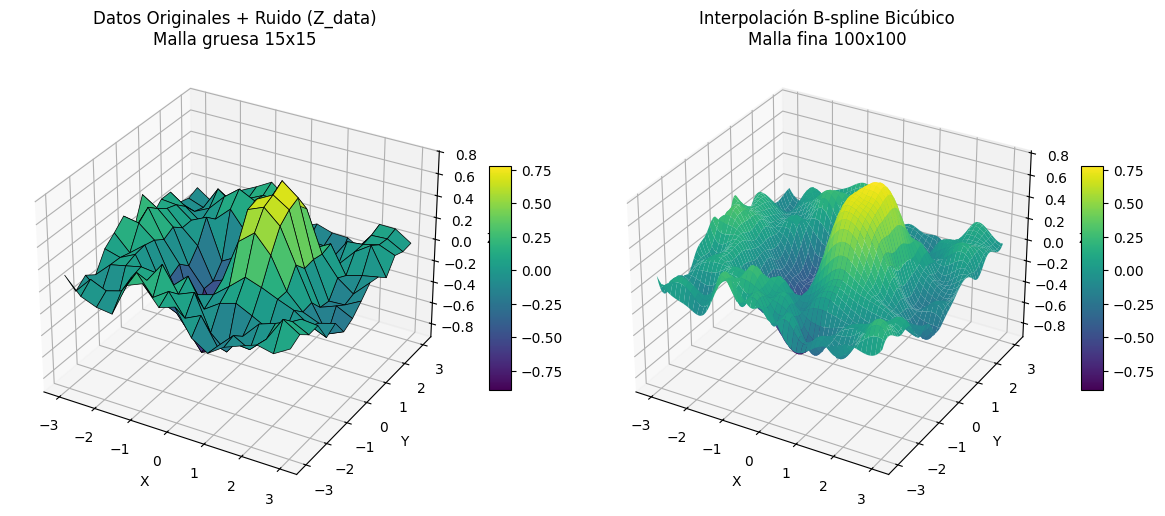

In [9]:
# TODO P2.2: figura comparativa datos vs spline
fig = plt.figure(figsize=(12, 5))

# Obtenemos vmin y vmax para mantener los mismos límites en ambas gráficas
vmin = min(np.min(Z_data), np.min(Z_fine))
vmax = max(np.max(Z_data), np.max(Z_fine))

# Panel izquierdo: Z_data (Malla gruesa)
ax1 = fig.add_subplot(121, projection='3d')
surf1 = ax1.plot_surface(X_raw, Y_raw, Z_data, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='k', linewidth=0.5)
ax1.set_title('Datos Originales + Ruido (Z_data)\nMalla gruesa 15x15')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10)

# Panel derecho: Spline interpolado (Malla fina)
ax2 = fig.add_subplot(122, projection='3d')
surf2 = ax2.plot_surface(X_fine, Y_fine, Z_fine, cmap='viridis', vmin=vmin, vmax=vmax, edgecolor='none')
ax2.set_title('Interpolación B-spline Bicúbico\nMalla fina 100x100')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10)

plt.tight_layout()
plt.show()


---
## P3 — Ajuste por mínimos cuadrados (20 pts)

Ajusten un **plano** $z = c_0 + c_1 x + c_2 y$ a los 225 puntos de la malla usando mínimos cuadrados. Trabajen con los datos ruidosos `Z_data`.

### P3.1 — Ajuste (10 pts)

Construyan la matriz $A$, resuelvan el sistema normal con `np.linalg.lstsq`, e impriman los coeficientes $c_0, c_1, c_2$ con 4 decimales.

In [16]:
# TODO P3.1: construcción de A y ajuste por mínimos cuadrados
# Aplanamos las matrices para construir la matriz del sistema (tamaño 225)
X_flat = X_raw.flatten()
Y_flat = Y_raw.flatten()
Z_flat = Z_data.flatten()

# Construcción de la matriz A: [1, x_i, y_i]
A = np.column_stack((np.ones_like(X_flat), X_flat, Y_flat))

# Solución por mínimos cuadrados: Ac = z
c, residuals, rank, s = np.linalg.lstsq(A, Z_flat, rcond=None)
c0, c1, c2 = c

print(f"Coeficientes del plano ajustado:")
print(f"c0 = {c0:.4f}")
print(f"c1 = {c1:.4f}")
print(f"c2 = {c2:.4f}")


Coeficientes del plano ajustado:
c0 = -0.0049
c1 = 0.0051
c2 = -0.0028


### P3.2 — Residuos y figura (10 pts)

Calculen el mapa de residuos: $R = Z_{\text{data}} - Z_{\text{plano}}$, donde $Z_{\text{plano}}$ es el plano evaluado en la malla gruesa.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: plano ajustado sobre la malla gruesa, con colorbar y ejes etiquetados.
- Panel derecho: mapa de residuos $R$, con colorbar, ejes etiquetados, y colormap **divergente** centrado en cero.

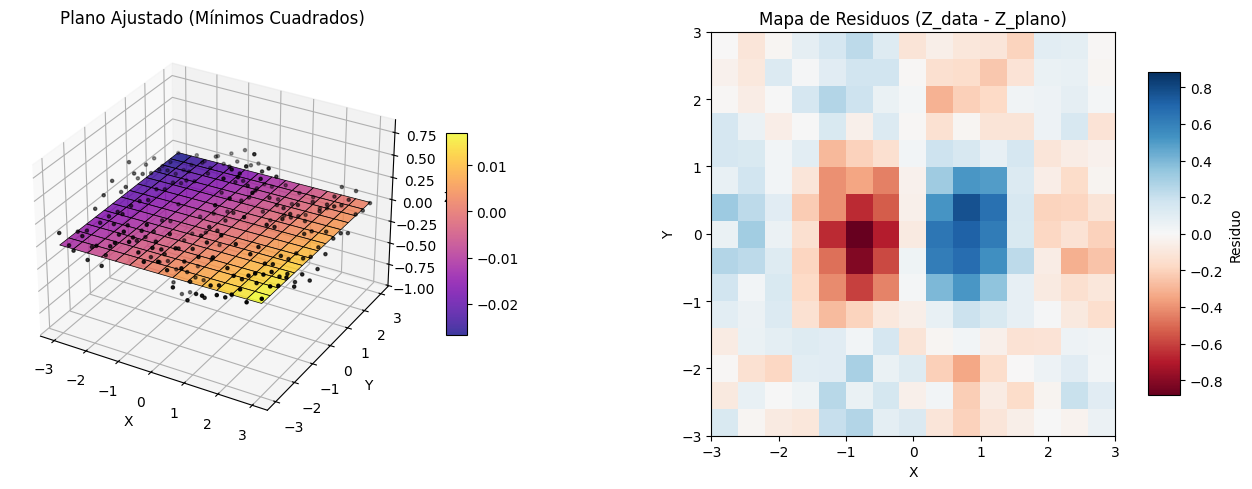

In [17]:
# TODO P3.2: plano ajustado y mapa de residuos
# Evaluamos el plano ajustado en la malla gruesa
Z_plano = c0 + c1 * X_raw + c2 * Y_raw

# Calculamos el mapa de residuos
R = Z_data - Z_plano

fig = plt.figure(figsize=(14, 5))

# Panel izquierdo: plano ajustado sobre la malla gruesa (3D)
ax1 = fig.add_subplot(121, projection='3d')
surf_plano = ax1.plot_surface(X_raw, Y_raw, Z_plano, cmap='plasma', edgecolor='k', linewidth=0.5, alpha=0.8)
# Opcional: mostrar los datos reales como puntos para contexto
ax1.scatter(X_raw, Y_raw, Z_data, color='k', s=5, label='Z_data')
ax1.set_title('Plano Ajustado (Mínimos Cuadrados)')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
fig.colorbar(surf_plano, ax=ax1, shrink=0.5, aspect=10)

# Panel derecho: Mapa de residuos en 2D (heatmap) con colormap divergente (e.g., coolwarm, RdBu)
ax2 = fig.add_subplot(122)
# Centramos el colormap divergente en 0 buscando el valor absoluto máximo
rmax = np.max(np.abs(R))
im_res = ax2.imshow(R.T, extent=[-3, 3, -3, 3], origin='lower', cmap='RdBu', vmin=-rmax, vmax=rmax)
ax2.set_title('Mapa de Residuos (Z_data - Z_plano)')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
fig.colorbar(im_res, ax=ax2, shrink=0.8, aspect=10, label='Residuo')

plt.tight_layout()
plt.show()


---
**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"
```

---
## P4 — PCA sobre señales sísmicas (15 pts)

Una red de 20 sensores sísmicos registra vibraciones del terreno durante 50 instantes
de tiempo. Las señales están contaminadas con ruido.

In [18]:
omega1 = 1.0 + (seed % 7) * 0.3
omega2 = 1.0 + (seed % 5) * 0.4

m, p = 20, 50
t = np.linspace(0, 2*np.pi, p)

rng2 = np.random.default_rng(seed + 1)
a = rng2.uniform(0.5, 2.0, m)
b = rng2.uniform(0.5, 2.0, m)

X = np.outer(a, np.cos(omega1 * t)) + np.outer(b, np.sin(omega2 * t))
X += rng.normal(0, 0.3, X.shape)

print(f"Señales: {m} sensores x {p} instantes")
print(f"omega1={omega1:.2f}, omega2={omega2:.2f}")

Señales: 20 sensores x 50 instantes
omega1=1.60, omega2=1.00


### P4.1 — Cálculo de componentes principales (7 pts)

Centren las filas de `X` y calculen la SVD con `np.linalg.svd`.

Produzcan una figura con **dos paneles**:
- Panel izquierdo: varianza explicada por cada componente (gráfico de barras).
- Panel derecho: varianza acumulada vs k (puntos + línea), con una línea
  horizontal punteada en el 85%.

Ambos paneles con ejes etiquetados y título.

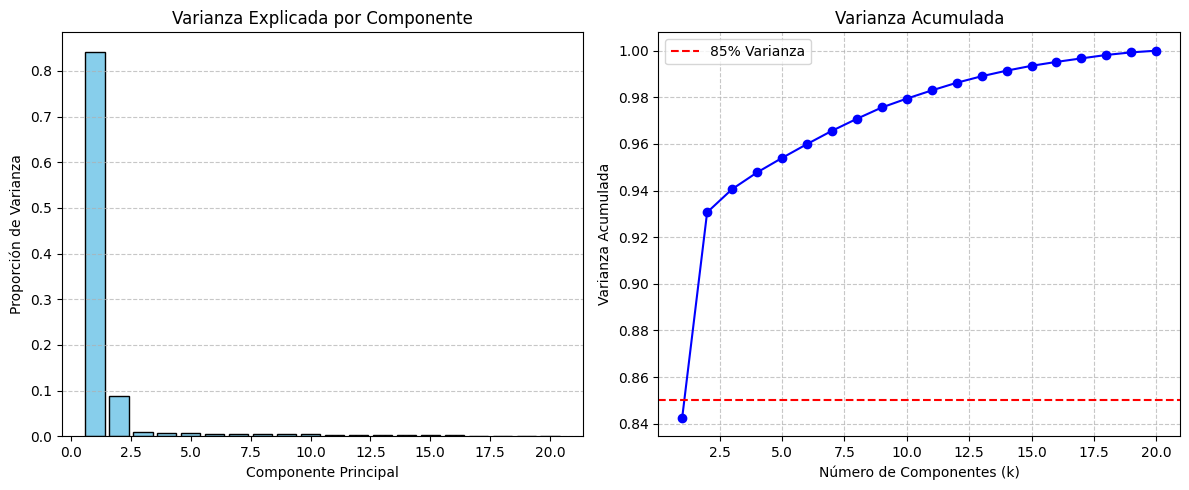

In [19]:
# TODO P4.1: Cálculo de componentes principales
# Centramos las filas de X (centramos cada señal sensada alrededor de 0 restando su media en el tiempo)
X_centered = X - np.mean(X, axis=1, keepdims=True)

# Cálculo de la SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

# Varianza explicada por cada componente (S^2) normalizada
varianza = (S ** 2) / (X_centered.shape[1] - 1)
var_explicada = varianza / np.sum(varianza)
var_acumulada = np.cumsum(var_explicada)

# Figura de dos paneles
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: Varianza explicada
k_components = len(S)
ax1.bar(range(1, k_components + 1), var_explicada, color='skyblue', edgecolor='k')
ax1.set_title('Varianza Explicada por Componente')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Proporción de Varianza')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Panel derecho: Varianza acumulada vs k
ax2.plot(range(1, k_components + 1), var_acumulada, marker='o', linestyle='-', color='b')
ax2.axhline(y=0.85, color='r', linestyle='--', label='85% Varianza')
ax2.set_title('Varianza Acumulada')
ax2.set_xlabel('Número de Componentes (k)')
ax2.set_ylabel('Varianza Acumulada')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### P4.2 — Proyección en el espacio PCA (8 pts)

Calculen los scores proyectando las 20 señales centradas sobre los primeros k
componentes que explique más del 89% de la varianza (2 o 3).

Produzcan un scatter de los 20 sensores en el espacio de los primeros k PCs:
- Si k=2: scatter PC1 vs PC2, coloreado por índice de sensor, con colorbar
  y etiquetas de sensor en cada punto.
- Si k=3: tres paneles PC1 vs PC2, PC1 vs PC3, PC2 vs PC3.

En todos los casos: ejes etiquetados con el nombre del componente (`"PC1"`, `"PC2"`...),
líneas en cero, grid, título con el porcentaje de varianza acumulada capturada.

Se utilizan 2 componentes para explicar el 93.1% de la varianza.


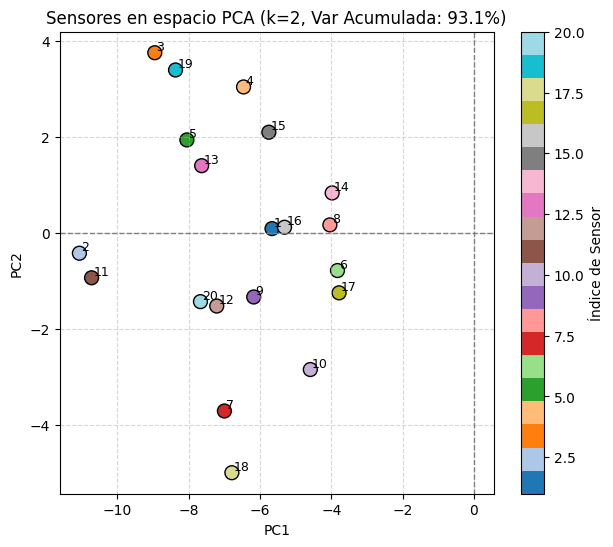

In [20]:
# TODO P4.2: Proyección en el espacio PCA
# Encontrar el número de componentes (k) necesarios para capturar más del 89% de varianza
k = np.argmax(var_acumulada > 0.89) + 1
var_k = var_acumulada[k-1] * 100
print(f"Se utilizan {k} componentes para explicar el {var_k:.1f}% de la varianza.")

# Proyección: Los "scores" de los sensores en el espacio PCA son X_centered @ V
# Equivalentemente por SVD: U * S
scores = U[:, :k] * S[:k]

if k == 2:
    fig, ax = plt.subplots(figsize=(7, 6))
    scatter = ax.scatter(scores[:, 0], scores[:, 1], c=range(1, m+1), cmap='tab20', s=100, edgecolor='k')

    # Etiquetas de sensor en cada punto
    for i in range(m):
        ax.text(scores[i, 0] + 0.05, scores[i, 1] + 0.05, str(i+1), fontsize=9)

    ax.axhline(0, color='grey', linestyle='--', linewidth=1)
    ax.axvline(0, color='grey', linestyle='--', linewidth=1)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(f'Sensores en espacio PCA (k=2, Var Acumulada: {var_k:.1f}%)')
    ax.grid(True, linestyle='--', alpha=0.5)
    fig.colorbar(scatter, ax=ax, label='Índice de Sensor')
    plt.show()

elif k >= 3:
    # Usaremos estrictamente 3 si k >= 3 para los paneles solicitados
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    pares = [(0, 1), (0, 2), (1, 2)]
    nombres = [('PC1', 'PC2'), ('PC1', 'PC3'), ('PC2', 'PC3')]

    for ax, (c1, c2), (n1, n2) in zip(axes, pares, nombres):
        scatter = ax.scatter(scores[:, c1], scores[:, c2], c=range(1, m+1), cmap='tab20', s=80, edgecolor='k')

        for i in range(m):
            ax.text(scores[i, c1]*1.02, scores[i, c2]*1.02, str(i+1), fontsize=8)

        ax.axhline(0, color='grey', linestyle='--', linewidth=1)
        ax.axvline(0, color='grey', linestyle='--', linewidth=1)
        ax.set_xlabel(n1)
        ax.set_ylabel(n2)
        ax.grid(True, linestyle='--', alpha=0.5)

    fig.suptitle(f'Proyección en espacio PCA (k={k}, Var Acumulada: {var_k:.1f}%)')
    fig.colorbar(scatter, ax=axes.ravel().tolist(), label='Índice de Sensor', shrink=0.8)
    plt.show()

---
## GitHub (10 pts)

Esta sección se califica directamente desde el PR. No hay celdas adicionales.

**Recordatorio del flujo:**

```bash
# 1. Crear y moverse a su rama
git checkout -b apellido1_apellido2_5Junio

# 2. Primer commit — después de P0 y P1
git add evaluacion_final_modulo.ipynb
git commit -m "init: cedulas, seed y generacion de datos"

# 3. Segundo commit — después de P2 y P3
git add evaluacion_final_modulo.ipynb
git commit -m "add: interpolacion spline y ajuste LS"

# 4. Tercer commit — después de P4 y todos los análisis escritos
git add evaluacion_final_modulo.ipynb
git commit -m "add: PCA y analisis escritos"

# 5. Push y abrir PR
git push origin apellido1_apellido2_5Junio
```

Luego en GitHub: **New Pull Request** → base: `main` ← compare: `apellido1_apellido2_5Junio`.

Título del PR: `Evaluación [Apellido1] [Apellido2]`
